In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.attractor_networks import HeadDirection, BatHeadDirectionSystem
import os
import tqdm

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

Ran warm up for 132 steps


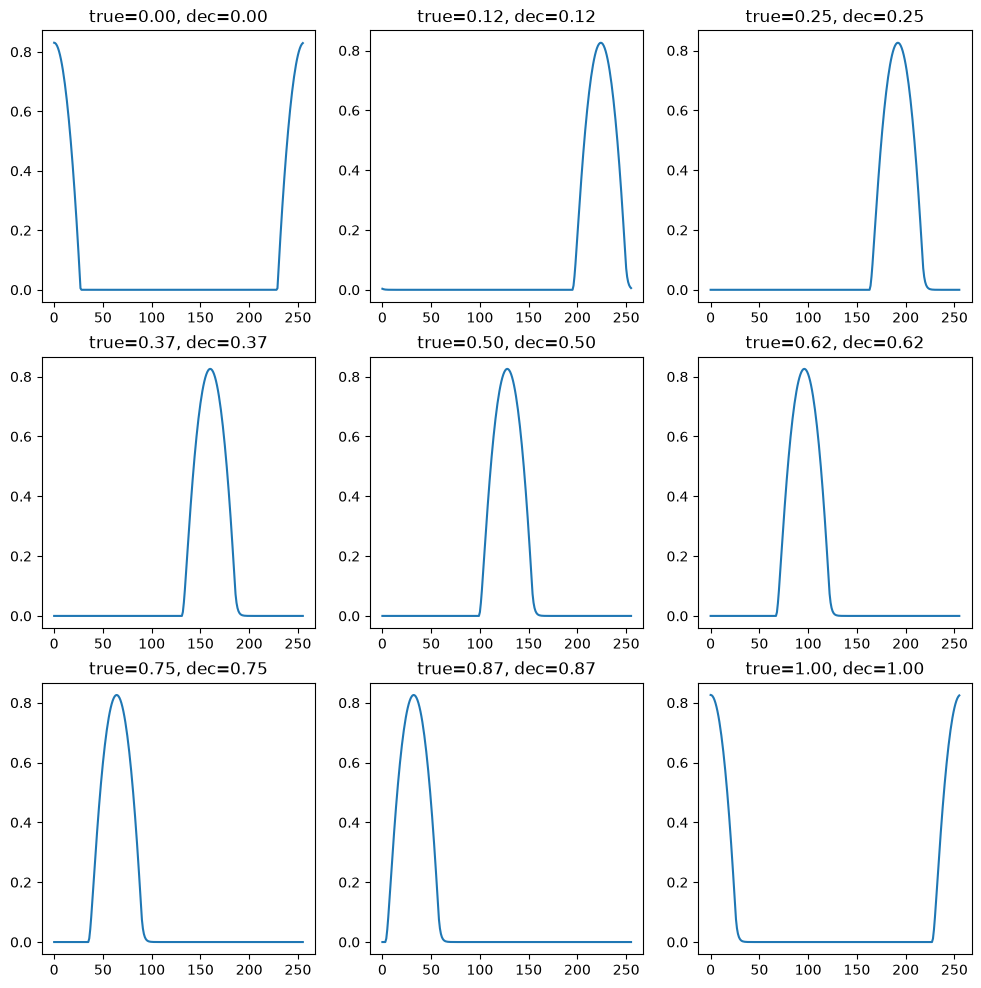

In [2]:
dt = 0.5e-3
n = 256
n_min_plots = 9

net = HeadDirection(n=(n), dt=dt, use_single_bump=True)
net.s = net.encode_orientation(0)
net.warm_up()
ncols = np.int64(np.ceil(np.sqrt(n_min_plots)))
nrows = np.int64(np.ceil(n_min_plots / ncols))
n_plots = nrows * ncols
fig, ax = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
ax = ax.flatten()
phi = 0
omega = 5
omega_max = 5
duration = int(0.02 / dt)
n_steps = int((2 * np.pi) / omega / dt)
records = np.linspace(0, n_steps - 1, n_plots, dtype=int)
plot_counter = 0
time = 0


for step_iter in range(n_steps):
    if step_iter == records[plot_counter]:
        decoded_angle = net.decode_orientation()
        ax[plot_counter].plot(net.s)
        ax[plot_counter].set_title(
            f"true={phi/(2*np.pi):.2f}, dec={decoded_angle[0]/(2*np.pi):.2f}"
        )
        plot_counter += 1
    net.step(np.array([omega]))
    phi += omega * dt
    time += dt

In [3]:
## Simulation parameters:
n_min_plots = 10
T = 400
dt = 0.5e-3
n = 256
net = BatHeadDirectionSystem()
net.warm_up()
bat_flight = generate_bat_flight(T=T, dt=dt)
n_steps = bat_flight["pos"].shape[0]

recording = net.run_simulation(bat_flight["dir_vel"])

Ran warm up for 288 steps


Running Simulation Steps: 100%|██████████| 800000/800000 [02:29<00:00, 5337.87it/s]


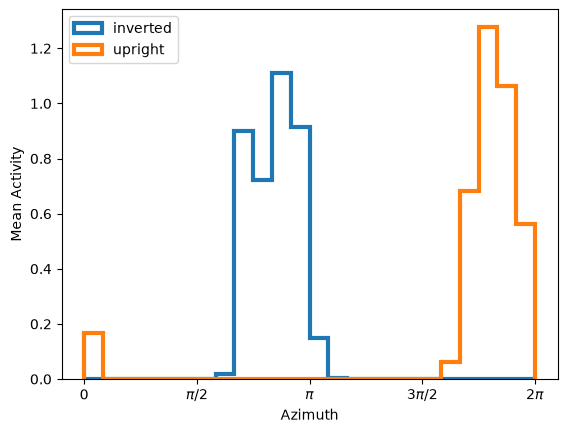

In [4]:
from grid_cells.plot_tools import activity_map

cell_index = 1
inverted = bat_flight["inverted"]
azimuth = bat_flight["dir_sphere"][:, 0] + np.pi
bins = np.linspace(0, 2 * np.pi, 25)

cell_recording = recording["azimuth_cells"][:, cell_index]
fig, ax = plt.subplots()  # subplot_kw={'projection': 'polar'}, layout='constrained')
plt.hist(
    azimuth[inverted],
    weights=cell_recording[inverted],
    bins=bins,
    label="inverted",
    density=True,
    histtype="step",
    linewidth=3,
)
plt.hist(
    azimuth[~inverted],
    weights=cell_recording[~inverted],
    bins=bins,
    label="upright",
    density=True,
    histtype="step",
    linewidth=3,
)
ax.set_xlabel("Azimuth")
ax.set_ylabel("Mean Activity")

ax.set_xticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
ax.legend(loc="best")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_inverted_pure_cell.png"))

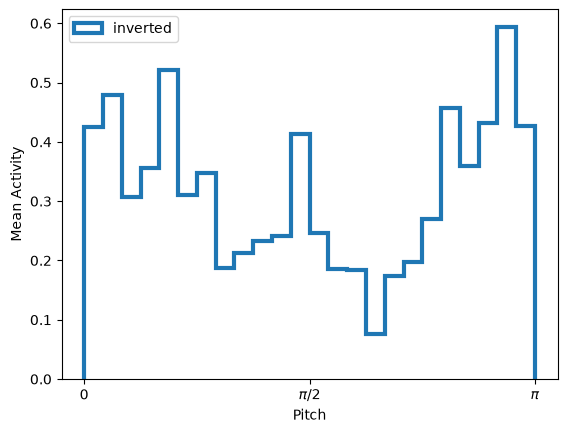

In [5]:
from grid_cells.plot_tools import activity_map

cell_index = 4
inverted = bat_flight["inverted"]
pitch = bat_flight["dir_sphere"][:, 1]
bins = np.linspace(0, np.pi, 25)

cell_recording = recording["pitch_cells"][:, cell_index]
fig, ax = plt.subplots()  # subplot_kw={'projection': 'polar'}, layout='constrained')
plt.hist(
    pitch,
    weights=cell_recording,
    bins=bins,
    label="inverted",
    density=True,
    histtype="step",
    linewidth=3,
)
ax.set_xlabel("Pitch")
ax.set_ylabel("Mean Activity")

ax.set_xticks(np.arange(0, 1.5, 0.5) * np.pi)
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$"])
ax.legend(loc="best")

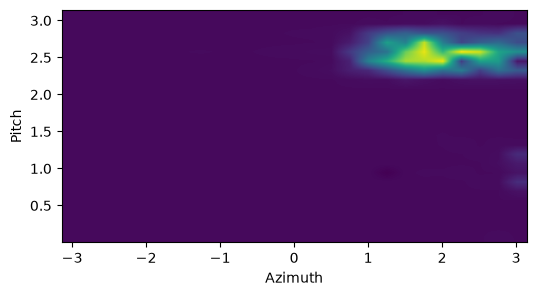

In [6]:
from grid_cells.plot_tools import activity_map

cell_index = 0
direction_activity_map, counts, direction_edges = activity_map(
    bat_flight["dir_sphere"], recording["conj_cells"][:, cell_index], nbins=25
)
fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(
    direction_activity_map,
    extent=(
        direction_edges[0][0],
        direction_edges[0][-1],
        direction_edges[1][0],
        direction_edges[1][-1],
    ),
    interpolation="bilinear",
    origin="lower",
)
ax.set_xlabel("Azimuth")
ax.set_ylabel("Pitch")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_direction_grid_aperiodic.png"))

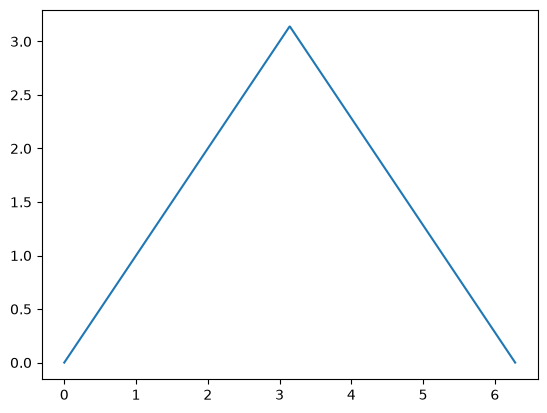

In [ ]:
def compute_heading(heading):
    current_azimuth = heading[..., 0]
    current_pitch = heading[..., 1]
    h_x = np.cos(current_pitch - np.pi / 2) * np.cos(current_azimuth)
    h_y = np.cos(current_pitch - np.pi / 2) * np.sin(current_azimuth)
    h_z = np.sin(current_pitch - np.pi / 2)
    current_heading = np.array([h_x, h_y, h_z]).T
    return current_heading


def compute_spherical_coordinates(heading):
    """
    Convert 3D Cartesian heading vector to spherical coordinates (azimuth, pitch).

    Args:
        heading: 3D heading vector or array of heading vectors.

    Returns:
        Array of (azimuth, pitch) angles in radians.
    """
    heading = np.asarray(heading, dtype=float)
    heading_norm = np.linalg.norm(heading, axis=-1, keepdims=True)
    heading = heading / np.clip(heading_norm, 1e-12, None)

    azimuth = np.arctan2(heading[..., 1], heading[..., 0])
    pitch = np.arcsin(np.clip(heading[..., 2], -1.0, 1.0)) + np.pi / 2

    return np.stack((azimuth, pitch), axis=-1)


pitch = np.linspace(0, 2 * np.pi, 100)
azimuth = np.ones_like(pitch) * np.pi

plt.plot(
    pitch,
    compute_spherical_coordinates(
        (compute_heading(np.stack([azimuth, pitch], axis=-1)))
    )[..., 1],
)

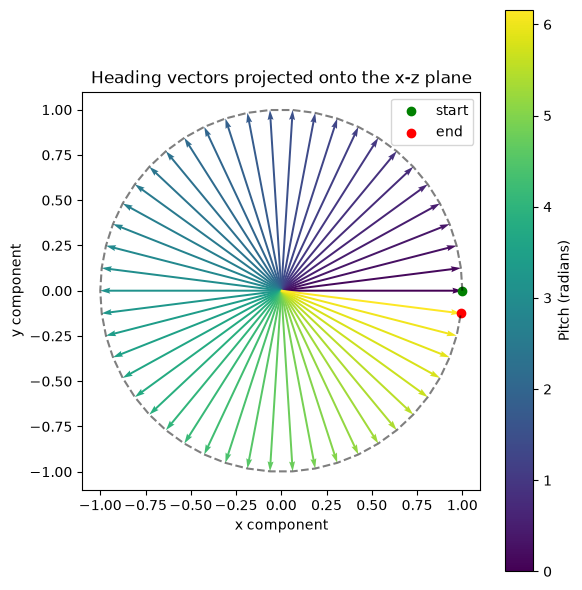

In [44]:
# Project the 3D heading vectors onto the x-z plane.
azimuth = np.linspace(0, 2 * np.pi, 50, endpoint=False)
heading_unit_vectors = compute_heading(
    np.stack([azimuth, np.full_like(azimuth, np.pi / 2)], axis=-1)
)
x = heading_unit_vectors[:, 0]
y = heading_unit_vectors[:, 1]

fig_2d, ax_2d = plt.subplots(figsize=(6, 6))

colors = pitch
ax_2d.quiver(
    x * 0,
    y * 0,
    x,
    y,
    colors,
    cmap="viridis",
    angles="xy",
    scale_units="xy",
    scale=1,
    alpha=1,
    width=0.005,
)

ax_2d.plot(x, y, color="black", alpha=0.5, ls="--")
ax_2d.scatter(x[0], y[0], color="green", label="start")
ax_2d.scatter(x[-1], y[-1], color="red", label="end")

ax_2d.set_aspect("equal")
ax_2d.set_xlim(-1.1, 1.1)
ax_2d.set_ylim(-1.1, 1.1)
ax_2d.set_xlabel("x component")
ax_2d.set_ylabel("y component")
ax_2d.set_title("Heading vectors projected onto the x-z plane")
ax_2d.legend()

fig_2d.colorbar(
    plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(pitch.min(), pitch.max())),
    ax=ax_2d,
    label="Pitch (radians)",
)
fig_2d.tight_layout()

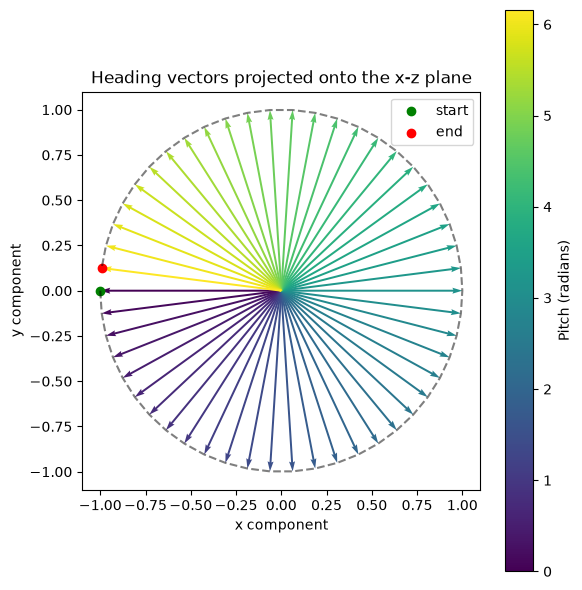

In [45]:
# Project the 3D heading vectors onto the x-z plane.
azimuth = np.linspace(0, 2 * np.pi, 50, endpoint=False)
heading_unit_vectors = compute_heading(
    np.stack([azimuth, np.full_like(azimuth, 3 * np.pi / 2)], axis=-1)
)
x = heading_unit_vectors[:, 0]
y = heading_unit_vectors[:, 1]

fig_2d, ax_2d = plt.subplots(figsize=(6, 6))

colors = pitch
ax_2d.quiver(
    x * 0,
    y * 0,
    x,
    y,
    colors,
    cmap="viridis",
    angles="xy",
    scale_units="xy",
    scale=1,
    alpha=1,
    width=0.005,
)

ax_2d.plot(x, y, color="black", alpha=0.5, ls="--")
ax_2d.scatter(x[0], y[0], color="green", label="start")
ax_2d.scatter(x[-1], y[-1], color="red", label="end")

ax_2d.set_aspect("equal")
ax_2d.set_xlim(-1.1, 1.1)
ax_2d.set_ylim(-1.1, 1.1)
ax_2d.set_xlabel("x component")
ax_2d.set_ylabel("y component")
ax_2d.set_title("Heading vectors projected onto the x-z plane")
ax_2d.legend()

fig_2d.colorbar(
    plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(pitch.min(), pitch.max())),
    ax=ax_2d,
    label="Pitch (radians)",
)
fig_2d.tight_layout()